In [7]:
from firedrake import *
from firedrake.output import VTKFile
import matplotlib.pyplot as plt
import numpy as np
from firedrake.petsc import PETSc
# Get current path: all relative paths that you may use for input/output start from here.
#
# - Colab:  The default path is /content, and your GDrive folder is accessible (if mounted) at /content/drive/MyDrive
#
# - local:  If running on your local machine, current_path is the position WHERE YOU LAUNCHED THE NOTEBOOK KERNEL BY 'jupyter notebook'
#           and NOT the directory in which this ipynb file is saved.
#           If you want to modify your current path, go to the terminal, stop the kernel (ctrl-C + press y), then move to the desired path by
#           cd my/desired/path/starting/from/here
#           and then launch 'jupyter notebook'.
import os
current_path = os.getcwd()
io_path = current_path + "/cfd-labs/Lab08-SNES-and-postprocessing/" 
print(io_path)

/home/aless/cfd-labs/Lab08-SNES-and-postprocessing/


# Ex.1 NS: Scalable Nonlinear Equations Solver (SNES) for the stationary problem.

We want to solve the following problem

\begin{equation*}
\begin{cases}
(\boldsymbol{u}\cdot\nabla)\boldsymbol{u} - {\rm div}(2\nu\varepsilon(\boldsymbol{u})) + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega, \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = 4y(1-y)\boldsymbol{i} & {\rm on} \ \Gamma_{\rm in}, \\
(2\nu\nabla\varepsilon(\boldsymbol{u}) - pI)\boldsymbol{n} = \boldsymbol{0} & {\rm on} \ \Gamma_{\rm out}, \\
\left[\begin{aligned}
\text{(i) }&\boldsymbol{u} = \boldsymbol{0}\\
\text{(ii) }&\boldsymbol{u}\cdot\boldsymbol{n} = 0, \quad (2\nu\nabla\varepsilon(\boldsymbol{u})-pI)\boldsymbol{n} \cdot \boldsymbol{t} = 0
\end{aligned}\right]
& {\rm on} \ \Gamma_{\rm wall}=\partial\Omega\setminus(\Gamma_{\rm in}\cup\Gamma_{\rm out}). \\
\end{cases}
\end{equation*}

but, instead of relying on Picard's or Networn's methods implemented in Python, we use SNES directly. In the sequel, we will focus on (ii).

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (31,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (32,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (33,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (41,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (42,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (43,) is empty. This is likely an error. Did you choose the right label?


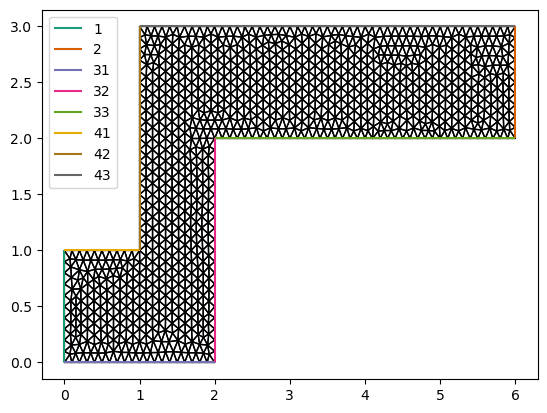

In [76]:
# Import mesh: set the path correctly!
# See cell before Exercise 1 about current path.
mesh = Mesh(io_path + 'elbow3bis.msh')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend(loc='upper left')

In [77]:
# Function spaces (mixed formulation)
V = VectorFunctionSpace(mesh, 'P', 2)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])

# Viscosity and source term
nu = 0.02
f = Constant((0.,0.))

# Boundary conditions
x = SpatialCoordinate(mesh)
u_in = as_vector((4.*x[1]*(1.-x[1]), 0.))
bc_wall_no_slip = DirichletBC(W.sub(0), Constant((0., 0.)), (31, 32, 33, 41, 42, 43))
bc_freeslip_x = DirichletBC(W.sub(0).sub(0), Constant(0.), (32,42))
bc_freeslip_y = DirichletBC(W.sub(0).sub(1), Constant(0.), (31,33,41,43))
bc_in = DirichletBC(W.sub(0), u_in, 1)
bcs_freeslip = [bc_freeslip_x, bc_freeslip_y, bc_in]
bcs_noslip = [bc_wall_no_slip, bc_in]

# Variational problem

# ---------------------------------------------------
# NO TRIAL FUNCTIONS since the problem is not linear. 
# ---------------------------------------------------
v, q = TestFunctions(W)

# -----------------------------------------------------------
# ATTENTION: wh, uh and ph must be created before creating G.
# If you re-define wh, uh or ph, you MUST re-compute G,
# since G is the evaluation of the residual on a specific wh.
# -----------------------------------------------------------
wh_freeslip = Function(W)
uh_freeslip, ph_freeslip = split(wh_freeslip) # NO: uh, ph = wh_freeslip.subfunctions
wh_noslip = Function(W)
uh_noslip, ph_noslip = split(wh_noslip) # NO: uh, ph = wh_noslip.subfunctions

# ------------------------------------------------------------------
# IDEA: we define a functional G that represents the residual of the 
# nonlinear problem and we will use SNES to solve G(wh) = 0.
# ------------------------------------------------------------------
def nonlinear_problem_residual(uh, v, ph, q, nu, f):
    """
    Compute the residual of the nonlinear problem for a given solution (uh, ph).
    Inputs:
        uh: Function representing the velocity field (NOT a trial function)
        v: TestFunction for the velocity field
        ph: Function representing the pressure field (NOT a trial function)
        q: TestFunction for the pressure field
        nu: Viscosity coefficient
        f: Source term (body force)
    Output:
        G: Linear form representing the residual of the nonlinear problem
    """
    G = 2*Constant(nu)*inner(sym(grad(uh)), sym(grad(v)))*dx  + inner(dot(grad(uh), uh), v)*dx  - div(v)*ph*dx  + q*div(uh)*dx - inner(f, v)*dx
    return G

# Define the residual functional G
G_freeslip= nonlinear_problem_residual(uh_freeslip, v, ph_freeslip, q, nu, f)
G_noslip= nonlinear_problem_residual(uh_noslip, v, ph_noslip, q, nu, f)

In [78]:
# -------------------------------------------------------------------------
# QUICK CHECK: we check the ranks of the residual form and a bilinear form.
# -------------------------------------------------------------------------

# The rank of a residual form is the number of trial and test functions it depends on,
# which is the same as the number of arguments of G, i.e. 1.
print("Rank of the residual form:", len(G_freeslip.arguments()))

# The rank of a bilinear form is the number of trial and test functions it depends on,
# which is the same as the number of arguments of a bilinear form, i.e. 2.
u, p = TrialFunctions(W)
print("Rank of a bilinear form  :", len((inner(u,v)*dx).arguments())) # 2: trial and test functions

Rank of the residual form: 1
Rank of a bilinear form  : 2


In [79]:
# Solve the nonlinear problem using SNES
param=({'snes_type':'newtonls',                  # nonlinear solver types: https://petsc.org/release/manual/snes/#the-nonlinear-solvers
       'snes_monitor':'',                        # activate logging options
       'snes_monitoring_lg_residualnorm':'',     # print ||G|| at each iteration
       'snes_rtol':1e-6, 'snes_atol':1e-10, 
       'snes_stol':1e-14, 'snes_maxit':1000
       })
print("Solving the nonlinear problem with freeslip boundary conditions with SNES...")
solve(G_freeslip == 0, wh_freeslip, bcs=bcs_freeslip, solver_parameters=param)
print("")
print("Solving the nonlinear problem with noslip boundary conditions with SNES...")
solve(G_noslip == 0, wh_noslip, bcs=bcs_noslip, solver_parameters=param)

# # Equivalently
# nlvpb = NonlinearVariationalProblem(G_freeslip, wh_freeslip, bcs=bcs_freeslip)
# solver = NonlinearVariationalSolver(nlvpb, solver_parameters=param)
# solver.solve()

Solving the nonlinear problem with freeslip boundary conditions with SNES...
  0 SNES Function norm 2.999908281035e-01
  1 SNES Function norm 8.639626283065e-02
  2 SNES Function norm 3.710459048974e-02
  3 SNES Function norm 1.315059597114e-02
  4 SNES Function norm 6.987260833123e-04
  5 SNES Function norm 2.873331013481e-06
  6 SNES Function norm 7.209387252744e-12

Solving the nonlinear problem with noslip boundary conditions with SNES...
  0 SNES Function norm 2.999908281035e-01
  1 SNES Function norm 9.562386749216e-02
  2 SNES Function norm 1.462544585782e-02
  3 SNES Function norm 7.890423585316e-04
  4 SNES Function norm 2.764485130737e-06
  5 SNES Function norm 1.338583127279e-11


Now we solve the following problem for the stream function $\psi$

\begin{equation*}
\begin{cases}
-\Delta \psi = \omega & {\rm in} \ \Omega, \\
\nabla \psi \cdot \boldsymbol{n} & {\rm on} \ \Gamma_{\rm in} \cup \Gamma_{\rm out}, \\
\psi = 2/3 & {\rm on} \ \Gamma_{\rm wall_1}, \\
\psi = 0 & {\rm on} \ \Gamma_{\rm wall_2}.
\end{cases}
\end{equation*}

In [80]:
Z = FunctionSpace(mesh, 'P', 1)
psi = TrialFunction(Z)
eta = TestFunction(Z)

a_stream = inner(grad(psi), grad(eta))*dx
omega_freeslip = rot(uh_freeslip)                           
L_stream = inner(omega_freeslip, eta)*dx
omega_noslip = rot(uh_noslip)
L_stream_noslip = inner(omega_noslip, eta)*dx

bc_wall1 = DirichletBC(Z, Constant(2/3), (41, 42, 43))
bc_wall2 = DirichletBC(Z, Constant(0), (31, 32, 33))
bcs_stream = (bc_wall1, bc_wall2)

psi_h_freeslip = Function(Z)
solve(a_stream == L_stream, psi_h_freeslip, bcs_stream)
psi_h_noslip = Function(Z)
solve(a_stream == L_stream_noslip, psi_h_noslip, bcs_stream)

In [81]:
# Post-processing

# ---------------------------------------------------------------------------
# WARNING: for post processing we need subfunctions of wh, not proxies uh, ph
# ---------------------------------------------------------------------------
uh_out_freeslip, ph_out_freeslip = wh_freeslip.subfunctions

outfile = VTKFile(io_path + "solution_freeslip.pvd")
uh_out_freeslip.rename("Velocity")
ph_out_freeslip.rename("Pressure")
psi_h_freeslip.rename("Stream Function")
outfile.write(uh_out_freeslip, ph_out_freeslip, psi_h_freeslip)

outfile = VTKFile(io_path + "solution_noslip.pvd")
uh_out_noslip, ph_out_noslip = wh_noslip.subfunctions
uh_out_noslip.rename("Velocity")
ph_out_noslip.rename("Pressure")
psi_h_noslip.rename("Stream Function")
outfile.write(uh_out_noslip, ph_out_noslip, psi_h_noslip)

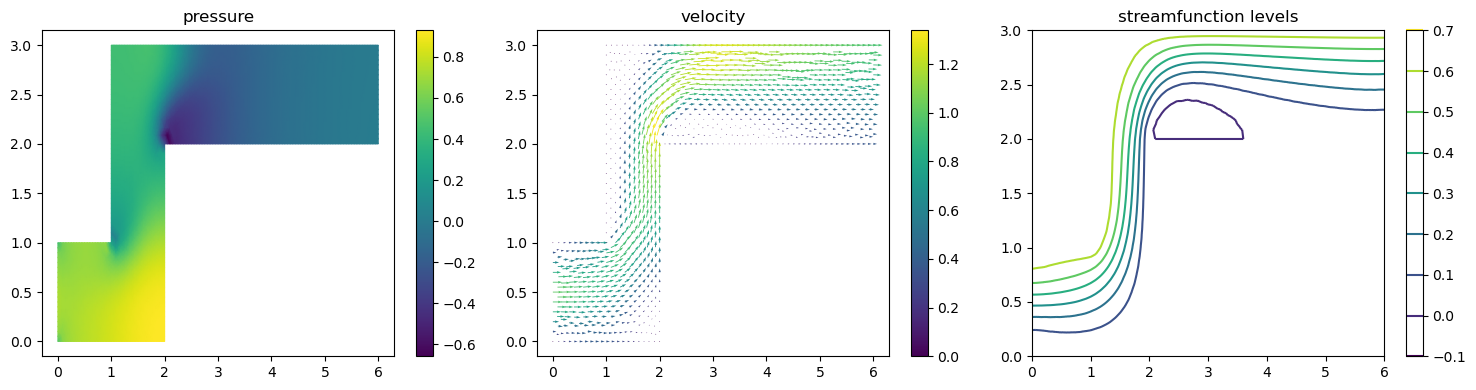

In [82]:
# Free slip solution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pressure
col1 = tripcolor(ph_out_freeslip, axes=axes[0])
fig.colorbar(col1, ax=axes[0])
axes[0].set_title('pressure')

# Velocity
col2 = quiver(uh_out_freeslip, axes=axes[1])
fig.colorbar(col2, ax=axes[1])
axes[1].set_title('velocity')

# Streamfunction
col3 = tricontour(psi_h_freeslip, axes=axes[2])
fig.colorbar(col3, ax=axes[2])
axes[2].set_title('streamfunction levels')

plt.tight_layout()
plt.show()

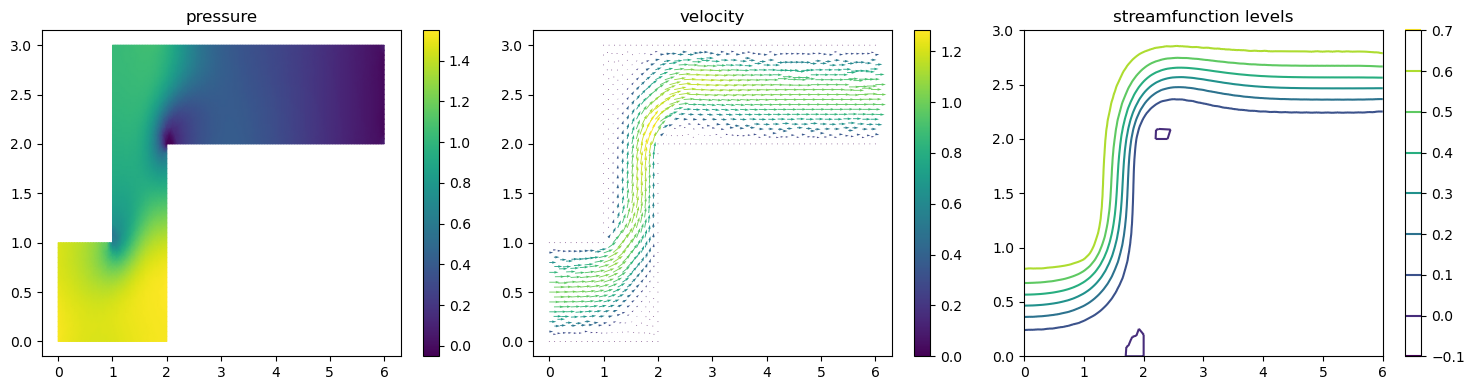

In [83]:
# No-slip solution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pressure
col1 = tripcolor(ph_out_noslip, axes=axes[0])
fig.colorbar(col1, ax=axes[0])
axes[0].set_title('pressure')

# Velocity
col2 = quiver(uh_out_noslip, axes=axes[1])
fig.colorbar(col2, ax=axes[1])
axes[1].set_title('velocity')

# Streamfunction
col3 = tricontour(psi_h_noslip, axes=axes[2])
fig.colorbar(col3, ax=axes[2])
axes[2].set_title('streamfunction levels')

plt.tight_layout()
plt.show()

Now we compute the following quantities of interest:

- Drag force exerted by the fluid onto the lower downstream wall $\Gamma_{33} = \{ x \in (2,6),\ y = 2 \}$

  $$
  F_D = - \int_{\Gamma} (2\nu \varepsilon(u) - pI)\, n \cdot i \, ds
  $$

- Flowrate through the outlet $\Gamma_{\text{out}}$

  $$
  Q_{\text{out}} = \int_{\Gamma_{\text{out}}} u \cdot n \, ds
  $$

- Total pressure jump

  $$
  \Delta p = p_{\text{in}} - p_{\text{out}} =
  \frac{1}{|\Gamma_{\text{in}}|} \int_{\Gamma_{\text{in}}} p \, ds
  - \frac{1}{|\Gamma_{\text{out}}|} \int_{\Gamma_{\text{out}}} p \, ds
  $$

In [89]:
# Quantities of interest: drag, flowrate, pressure jump

# Normal vector
normal = FacetNormal(mesh)

print("No-slip solution")
print('----------------')
# We neglet the contribution of the pressure to the drag force, since n is orthogonal to the x-axis on Γ_33.
drag = assemble(inner(dot(-Constant(2*nu)*sym(grad(uh_noslip)), normal), Constant((1.0, 0.0)))*ds(33))
print(f'Drag force on Γ_33    : {drag:.6f}')

flowrate = assemble(inner(uh_noslip, normal)*ds(2))
print(f'Outlet flowrate       : {flowrate:.6f}')
print(f'Exact outlet flowrate : {2.0/3.0:.6f}')

I1 = assemble(ph_out_noslip * ds(1))
I2 = assemble(ph_out_noslip * ds(2))
L1 = assemble(Constant(1.0) * ds(1, domain=mesh))
L2 = assemble(Constant(1.0) * ds(2, domain=mesh))
delta_p = I1 / L1 - I2 / L2
print(f'Total pressure jump   : {delta_p:.6f}')

print("\nFree-slip solution")
print("------------------")
# We neglet the contribution of the pressure to the drag force, since n is orthogonal to the x-axis on Γ_33.
drag = assemble(inner(dot(-Constant(2*nu)*sym(grad(uh_freeslip)), normal), Constant((1.0, 0.0)))*ds(33))
print(f'Drag force on Γ_33    : {drag:.6f}')
print(f'Exact drag force      : {0.0:.6f}')

flowrate = assemble(inner(uh_freeslip, normal)*ds(2))
print(f'Outlet flowrate       : {flowrate:.6f}')
print(f'Exact outlet flowrate : {2.0/3.0:.6f}')

I1 = assemble(ph_out_freeslip * ds(1))
I2 = assemble(ph_out_freeslip * ds(2))
L1 = assemble(Constant(1.0) * ds(1, domain=mesh))
L2 = assemble(Constant(1.0) * ds(2, domain=mesh))
delta_p = I1 / L1 - I2 / L2
print(f'Total pressure jump   : {delta_p:.6f}')

No-slip solution
----------------
Drag force on Γ_33    : 0.216807
Outlet flowrate       : 0.666667
Exact outlet flowrate : 0.666667
Total pressure jump   : 1.494485

Free-slip solution
------------------
Drag force on Γ_33    : 0.001793
Exact drag force      : 0.000000
Outlet flowrate       : 0.666667
Exact outlet flowrate : 0.666667
Total pressure jump   : 0.665118


# Ex.2 NS: SNES and time-dependent problem.

Now we use SNES to solve the following time-dependent problem

\begin{equation*}
\begin{cases}
\frac{\partial\boldsymbol{u}}{\partial t} + (\boldsymbol{u}\cdot\nabla)\boldsymbol{u} - \frac{2}{\rm Re}{\rm div}\,\varepsilon(\boldsymbol{u}) + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega, t\in(0,T), \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, t\in(0,T), \\
\boldsymbol{u} = 1\boldsymbol{i} & {\rm on} \ \Gamma_{\rm in}, t\in(0,T), \\
\left(\frac{2}{\rm Re}\varepsilon(\boldsymbol{u}) - pI\right)\boldsymbol{n} = \boldsymbol{0} & {\rm on} \ \Gamma_{\rm out}, t\in(0,T), \\
\boldsymbol{u}\cdot\boldsymbol{n} = 0, \quad \left(\frac{2}{\rm Re}\varepsilon(\boldsymbol{u})-pI\right)\boldsymbol{n} \cdot \boldsymbol{t} = 0
& {\rm on} \ \Gamma_{\rm wall}, t\in(0,T),\\
\boldsymbol{u}=\boldsymbol{0} & {\rm on} \ \Gamma_{\rm cyl}, t\in(0,T),\\
\boldsymbol{u}=\boldsymbol{0} & {\rm in} \ \Omega, t=0.
\end{cases}
\end{equation*}

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (5,) is empty. This is likely an error. Did you choose the right label?


(np.float64(-3.75), np.float64(12.75), np.float64(-2.2), np.float64(2.2))

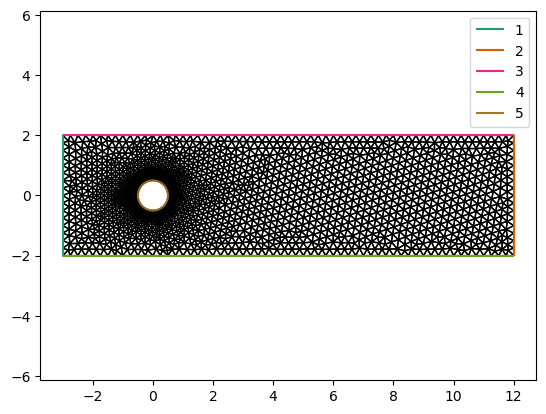

In [71]:
# Import mesh: set the path correctly!
# See cell before Exercise 1 about current path.
mesh = Mesh(io_path+'cylinder-ns.msh')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend(loc='upper right')
ax.axis('equal')

### FE spaces, data, BCs

In [ ]:
...

### Variational problem - residual

In [ ]:
# inputs:   uh, ph  components of an actual Function (NOT trial functions)
#           v, q    components of a TestFunction
#           nu, f   viscosity and source function
#           dt      time step
#           uh_old  velocity at previous timestep
# output:   G       linear form (i.e. functional) representing the evaluation of
#                   the residual for a given solution (uh,ph), for any test function
def nonlinear_problem_residual(uh, v, ph, q, nu, f, dt, uh_old):
    G = ...
    return G

### Initial condition and settings

In [ ]:
uh_old = interpolate(Constant((0., 0.)), W.sub(0))

wh = Function(W)
uh, ph = split(wh)
# NB:   wh (and also uh,ph) must be created and properly set before assembling G.
#       If wh (or uh,ph) changes, you MUST re-assemble G,
#       since G is the evaluation of the residual on a specific wh.
uh_out, ph_out = wh.subfunctions
uh_out.assign(uh_old)       # must be done through a subfunction, not through a split component
v, q = TestFunctions(W)

t0 = 0
T = 10.
dt = 0.2
export_stride = 5     # export solution every other export_stride timesteps
time_index = 0

param = ...

basename = 'lab08_cylinder_'
outfileU = File(my_io_path+"cyl-ns/"+basename+"velocity.pvd")
outfileP = File(my_io_path+"cyl-ns/"+basename+"pressure.pvd")
uh_out.rename('Velocity')
ph_out.rename('Pressure')
outfileU.write(uh_out, time=0)
outfileP.write(ph_out, time=0)

In [ ]:
for t in np.arange(t0, T+0.1*dt, dt):
    print('\ntime t = ', t)
    time_index += 1

    ... assemble and solve ...

    if time_index % export_stride == 0:
        ... rename solution variables and write to pvd files ...

    uh_old.assign(uh_out)